# Flight Price Prediction — Exploratory Data Analysis

Explore the **flights** dataset used to train the price regression model.

Model inputs: `from`, `to`, `flightType`, `agency`, `time`, `distance`  
Target: `price`

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate voyage-analytics project root")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.data.ingestion import DataIngestion

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load data

In [2]:
flights_df = DataIngestion().load_flights_data()
flights_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


**Insight:** Each row is one flight booking leg. Round trips appear as two rows (outbound + return). `travelCode`, `userCode`, and `date` are **not** used by the current regression API.

## 2. Dataset overview

In [3]:
print(f"Rows: {len(flights_df):,}  |  Columns: {flights_df.shape[1]}")
print(f"Date range: {flights_df['date'].min()} → {flights_df['date'].max()}")
print(f"Unique routes (from→to): {flights_df.groupby(['from', 'to']).ngroups:,}")

flights_df.info()
flights_df.describe().T

Rows: 271,888  |  Columns: 10
Date range: 01/01/2021 → 12/31/2022
Unique routes (from→to): 70
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


,count,mean,std,min,25%,50%,75%,max
travelCode,271888.0,67971.500000,39243.724665,0.00,33985.75,67971.50,101957.25,135943.00
userCode,271888.0,667.505495,389.523127,0.00,326.00,659.00,1011.00,1339.00
price,271888.0,957.375030,362.311890,301.51,672.66,904.00,1222.24,1754.17
time,271888.0,1.421147,0.542541,0.44,1.04,1.46,1.76,2.44
distance,271888.0,546.955535,208.851288,168.22,401.66,562.14,676.53,937.77


**Insight:** ~272k records with many unique origin–destination pairs. Large scale supports robust regression, but high route cardinality increases one-hot feature dimensionality.

## 3. Missing values

In [4]:
missing = flights_df.isna().sum().sort_values(ascending=False)
pd.DataFrame({"missing": missing, "pct": (missing / len(flights_df) * 100).round(3)})

,missing,pct
travelCode,0,0.0
userCode,0,0.0
from,0,0.0
to,0,0.0
flightType,0,0.0
price,0,0.0
time,0,0.0
distance,0,0.0
agency,0,0.0
date,0,0.0


**Insight:** No missing values detected — the dataset is clean and ready for modeling without imputation.

## 4. Target variable — price

In [5]:
flights_df["price"].describe().round(2)

count    271888.00
mean        957.38
std         362.31
min         301.51
25%         672.66
50%         904.00
75%        1222.24
max        1754.17
Name: price, dtype: float64

**Insight:** Prices range roughly **$300–$1,700** with mean ~$930. The distribution is right-skewed (a few expensive first-class tickets pull the mean up).

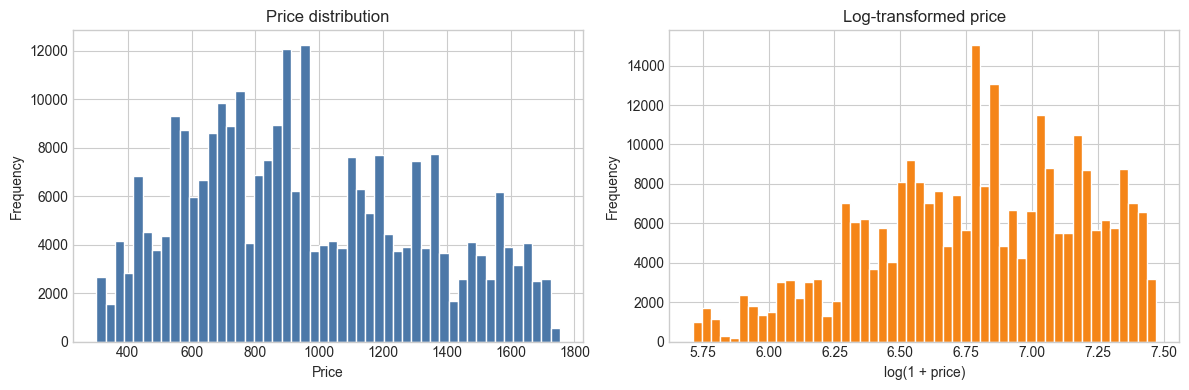

In [6]:
# Compare raw vs log price — log reduces right skew
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(flights_df["price"], bins=50, color="#4C78A8", edgecolor="white")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(flights_df["price"]), bins=50, color="#F58518", edgecolor="white")
axes[1].set_title("Log-transformed price")
axes[1].set_xlabel("log(1 + price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insight:** Raw price is right-skewed; the log histogram is more symmetric. Log-transforming the target is an optional experiment if residuals are skewed.

## 5. Categorical features

In [7]:
for col in ["flightType", "agency"]:
    print(f"\n{col} value counts:")
    display(flights_df[col].value_counts())


flightType value counts:


flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64


agency value counts:


agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64

**Insight:** Three cabin classes (`firstClass`, `premium`, `economic`) are fairly balanced. `firstClass` is slightly more common — expect it to correlate with higher prices.

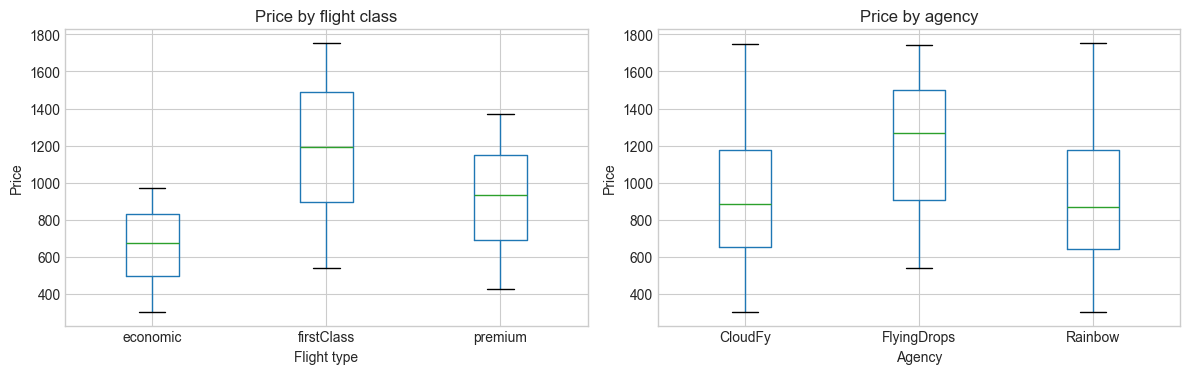

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

flights_df.boxplot(column="price", by="flightType", ax=axes[0])
axes[0].set_title("Price by flight class")
axes[0].set_xlabel("Flight type")
axes[0].set_ylabel("Price")

flights_df.boxplot(column="price", by="agency", ax=axes[1])
axes[1].set_title("Price by agency")
axes[1].set_xlabel("Agency")
axes[1].set_ylabel("Price")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Insight:** Boxplots show a clear **price ladder**: `firstClass` > `premium` > `economic`. `flightType` will be one of the strongest predictors.

In [9]:
print(f"Unique origins: {flights_df['from'].nunique()}")
print(f"Unique destinations: {flights_df['to'].nunique()}")

top_routes = (
    flights_df.groupby(["from", "to"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="count")
)
top_routes

Unique origins: 9
Unique destinations: 9


,from,to,count
0,Florianopolis (SC),Aracaju (SE),8643
1,Aracaju (SE),Florianopolis (SC),8643
2,Campo Grande (MS),Florianopolis (SC),8253
3,Florianopolis (SC),Campo Grande (MS),8253
4,Brasilia (DF),Florianopolis (SC),7779
5,Florianopolis (SC),Brasilia (DF),7779
6,Recife (PE),Florianopolis (SC),7609
7,Florianopolis (SC),Recife (PE),7609
8,Florianopolis (SC),Sao Paulo (SP),6717
9,Sao Paulo (SP),Florianopolis (SC),6717


**Insight:** A few routes dominate booking volume. Popular routes may have more stable average prices; rare routes can be noisier.

## 6. Numerical features & correlations

In [ ]:
numeric_cols = ["price", "time", "distance"]
flights_df[numeric_cols].corr().round(3)

**Insight:** `distance` correlates positively with `price` (longer flights cost more). `time` also correlates but partly overlaps with distance — both are useful numerical features.

In [ ]:
# Sample 10k points for readable scatter plots on 272k rows
sample_df = flights_df.sample(n=min(10_000, len(flights_df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(sample_df["distance"], sample_df["price"], alpha=0.2, s=8, color="#4C78A8")
axes[0].set_title("Price vs distance (10k sample)")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Price")

axes[1].scatter(sample_df["time"], sample_df["price"], alpha=0.2, s=8, color="#F58518")
axes[1].set_title("Price vs flight time (10k sample)")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

**Insight:** Scatter plots show a **positive trend** with wide spread at each distance — route, agency, and cabin class explain the vertical scatter.

In [ ]:
avg_price_by_type = flights_df.groupby("flightType")["price"].mean().sort_values(ascending=False)
avg_price_by_agency = flights_df.groupby("agency")["price"].mean().sort_values(ascending=False)

pd.DataFrame({
    "avg_price_by_flight_type": avg_price_by_type,
}).round(2)

**Insight:** Mean price by class confirms the ranking seen in boxplots. Agency-level averages can reveal pricing differences between `Rainbow`, `CloudFy`, and `FlyingDrops`.

## 7. Temporal patterns

In [ ]:
flights_df["date_parsed"] = pd.to_datetime(flights_df["date"], format="%m/%d/%Y", errors="coerce")
monthly = (
    flights_df.dropna(subset=["date_parsed"])
    .groupby(flights_df["date_parsed"].dt.to_period("M"))["price"]
    .agg(["count", "mean"])
    .tail(12)
)
monthly

**Insight:** Monthly booking counts and average prices reveal seasonality. Date is excluded from the current model but could improve predictions in future iterations.

In [ ]:
monthly["mean"].plot(kind="line", figsize=(10, 4), marker="o", color="#4C78A8")
plt.title("Average ticket price by month (last 12 months in data)")
plt.xlabel("Month")
plt.ylabel("Mean price")
plt.tight_layout()
plt.show()

**Insight:** The line chart highlights months where average fares rise or fall — useful for pricing strategy even though the API model ignores date.

## 8. Modeling notes

- Preprocessing one-hot encodes route and agency features and scales `time` / `distance` (see `src/data/preprocessing.py`).
- `travelCode`, `userCode`, and `date` are not used by the current regression API.
- High cardinality on `from` / `to` increases feature space; consider route grouping or target encoding in future experiments.

In [ ]:
summary = {
    "records": len(flights_df),
    "median_price": round(flights_df["price"].median(), 2),
    "price_std": round(flights_df["price"].std(), 2),
    "flight_types": flights_df["flightType"].nunique(),
    "agencies": flights_df["agency"].nunique(),
    "unique_routes": flights_df.groupby(["from", "to"]).ngroups,
    "price_distance_corr": round(flights_df["price"].corr(flights_df["distance"]), 3),
}
pd.Series(summary, name="flight_prediction_eda")

**Insight — key takeaways:** `flightType` and `distance` are primary price drivers. Large categorical cardinality on routes needs one-hot encoding. Clean data, no imputation required.